reading data...
data loading finished, transferring to DataFrame...
      Model   Dose      Metric     Value     Type
0  CellFlow  0.001   r_squared  0.538626  General
1  CellFlow  0.001  e_distance  0.772395  General
2  CellFlow  0.001         mmd  0.037543  General
3  CellFlow  0.001   r_squared  0.662536  General
4  CellFlow  0.001  e_distance  0.347885  General


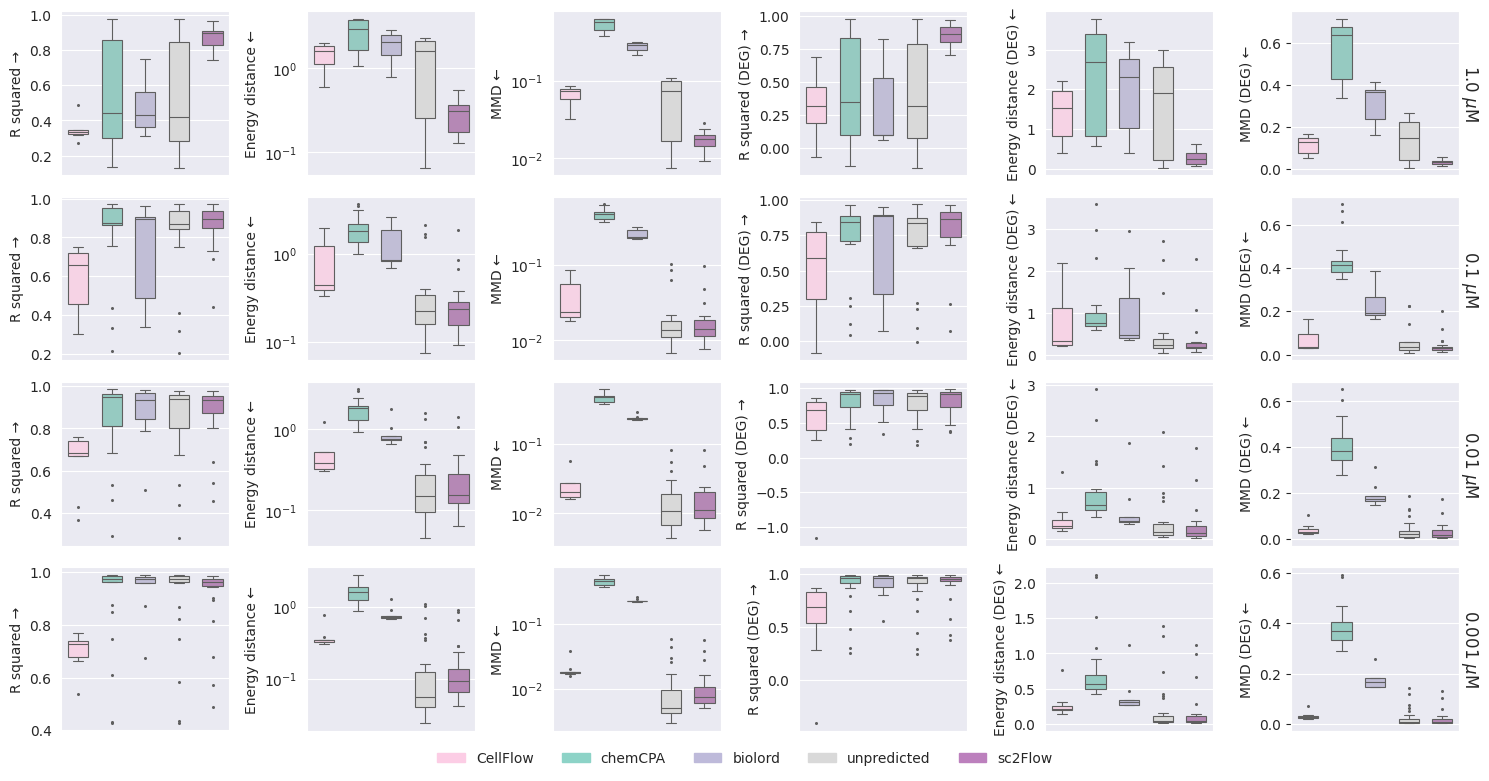

In [3]:
import os
import pickle
import torch
import numpy as np
import pandas as pd

model_path_config = {
    'biolord': '/home/usr/sc2Flow_lab/biolord/results',
    'chemCPA': '/home/usr/sc2Flow_lab/chemCPA/chemCPA/results/',
    'sc2Flow': '/home/usr/sc2Flow_lab/sc2Flow/output',
    'unpredicted': '/home/sc2Flow_lab/usr/sc2Flow/unpredicted/output',
    'cellFlow': '/home/usr/sc2Flow_lab/CellFlow/output/result',
}

models_list = ['CellFlow','chemCPA', 'biolord', 'unpredicted','sc2Flow',]
model_rename_map = {
    'chemCPA': 'chemCPA',
    'biolord': 'biolord',
    'sc2Flow': 'sc2Flow',
    'unpredicted':'unpredicted',
    'CellFlow':'CellFlow'
}

target_doses = ['10.0', '1.0', '0.1', '0.01']

records = []

print("reading data...")

for model_name in models_list:
            dataset='sciplex'
            split_key = 'mode'

            # Since we didn't set a unified path configuration method, conditional handling is required.
            # We will improve this in future versions.
            if model_name in ['sc2Flow','CellFlow','unpredicted',]:
                res_path = f'{model_path_config[model_name]}/{dataset}/{split_key}/res.pkl'
                res_de_path = f'{model_path_config[model_name]}/{dataset}/{split_key}/res_de.pkl'
            elif model_name in ['biolord','chemCPA']:
                res_path = f'{model_path_config[model_name]}/{dataset}/{split_key}/res.pkl'
                res_de_path = f'{model_path_config[model_name]}/{dataset}/{split_key}/res_deg.pkl'
            else:
                raise ValueError(f"[Error] Unknown model: {model_name}")

            if not os.path.exists(res_path) or not os.path.exists(res_de_path):
                print(f"[Warning] Path missing for {model_name}")
                continue

            # load results
            with open(res_path, 'rb') as f:
                result = pickle.load(f)
            with open(res_de_path, 'rb') as f:
                result_de = pickle.load(f)

            # all genes
            for key, metrics in result.items():
                try:
                    if model_name == 'biolord':
                        dose_str = key[0].rsplit('_', 1)[-1]
                    else:
                        dose_str = key.rsplit('_', 1)[-1]
                except:
                    continue

                for m, v in metrics.items():

                    if torch.is_tensor(v):
                        val = v.item()
                    else:
                        val = float(v)

                    if np.isnan(val): continue

                    records.append({
                        'Model': model_rename_map.get(model_name, model_name),
                        'Dose': dose_str,
                        'Metric': m,
                        'Value': val,
                        'Type': 'General'
                    })

            # DEGs
            for key, metrics in result_de.items():
                try:
                    if model_name == 'biolord':
                        dose_str = key[0].rsplit('_', 1)[-1]
                    else:
                        dose_str = key.rsplit('_', 1)[-1]
                except:
                    continue

                for m, v in metrics.items():
                    if torch.is_tensor(v):
                        val = v.item()
                    else:
                        val = float(v)

                    if np.isnan(val): continue

                    metric_name = m

                    metric_name = metric_name + '_de'

                    records.append({
                        'Model': model_rename_map.get(model_name, model_name),
                        'Dose': dose_str,
                        'Metric': metric_name,
                        'Value': val,
                        'Type': 'DE'
                    })

print("data loading finished, transferring to DataFrame...")
df = pd.DataFrame(records)

print(df.head())

import matplotlib.pyplot as plt
import seaborn as sns

metrics_to_plot = [
    ('r_squared', 'R squared →', False),
    ('e_distance', 'Energy distance ←', True),
    ('mmd', 'MMD ←', True),
    ('r_squared_de', 'R squared (DEG) →', False),
    ('e_distance_de', 'Energy distance (DEG) ←', True),
    ('mmd_de', 'MMD (DEG) ←', True),
]

available_metrics = df['Metric'].unique()
plot_metrics = [m for m in metrics_to_plot if m[0] in available_metrics]

doses_ordered = sorted(df['Dose'].unique(), key=lambda x: float(x), reverse=True)
# reverse=True -> 10, 1, 0.1, 0.01

palette = {
    'CellFlow': '#fccde5',
    'chemCPA': '#8dd3c7',
    'biolord': '#bebada',
    'unpredicted': '#d9d9d9',
    'sc2Flow': '#bc80bd',

}

n_rows = len(doses_ordered)
n_cols = len(plot_metrics)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 2 * n_rows), sharex=True)

plt.subplots_adjust(wspace=0.15, hspace=0.1)

for i, dose in enumerate(doses_ordered):
    df_dose = df[df['Dose'] == dose]

    for j, (metric_key, metric_label, use_log) in enumerate(plot_metrics):
        ax = axes[i, j]

        data_subset = df_dose[df_dose['Metric'] == metric_key]

        if len(data_subset) == 0:
            ax.set_visible(False)
            continue

        sns.boxplot(
            data=data_subset,
            x='Model',
            y='Value',
            hue='Model',
            palette=palette,
            ax=ax,
            dodge=False,
            width=0.6,
            linewidth=0.8,
            fliersize=1.2
        )

        ax.set_ylabel(metric_label)

        if metric_key in ['e_distance', 'mmd']:
            ax.set_yscale('log')

        ax.set_xlabel('')
        ax.set_xticklabels([])
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

        if j == n_cols - 1:
            ax2 = ax.twinx()
            ax2.set_ylabel(f"{dose} $\mu$M", rotation=270, labelpad=15, fontsize=12)
            ax2.set_yticks([])


import matplotlib.patches as mpatches
plt.tight_layout(rect=[0, 0.05, 1, 1])


legend_handles = [
    mpatches.Patch(color=color, label=label)
    for label, color in palette.items()
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.02),
    ncol=len(palette),
    frameon=False,
    fontsize=10
)
plt.savefig('./benchmark_results.pdf', bbox_inches='tight')
plt.show()